<a href="https://colab.research.google.com/github/shaikhisg/balkhash/blob/main/scripts/NDVI_Reclamation_Monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

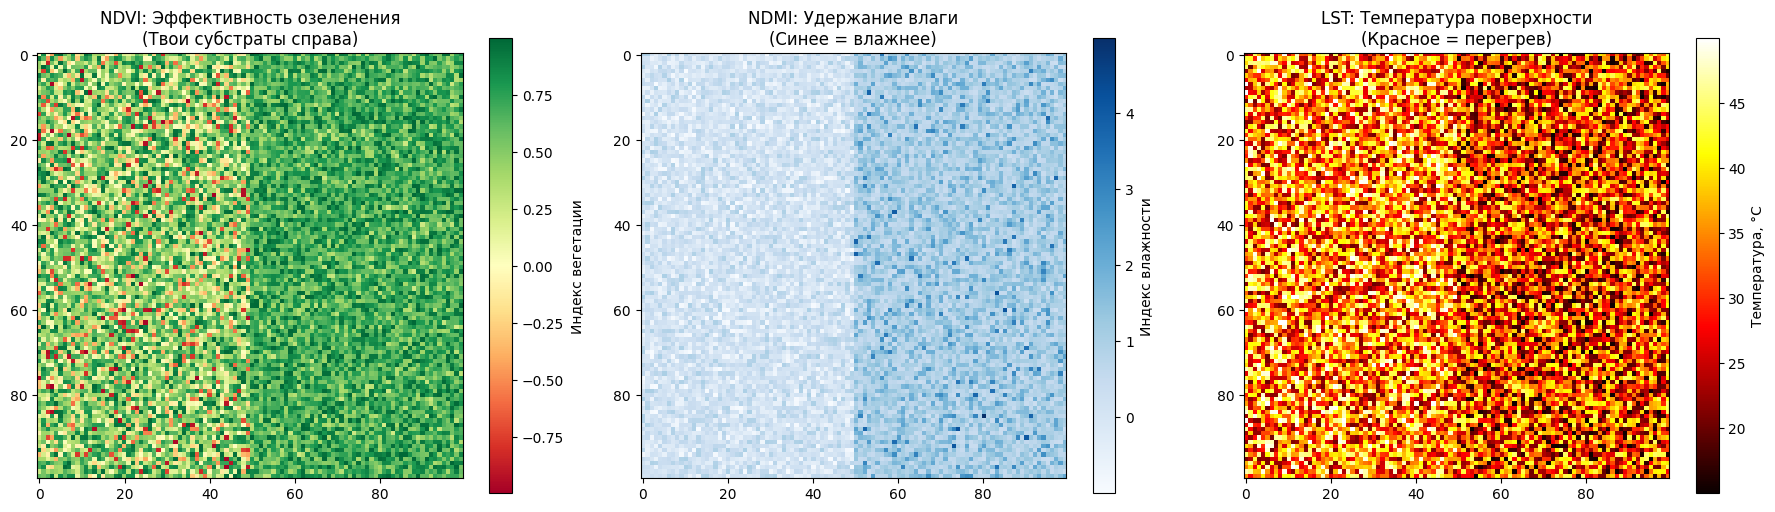

Анализ завершен: Техноземы на основе окисленного угля показывают лучшую приживаемость растений и удержание влаги.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. СОЗДАЕМ МОДЕЛЬ УЧАСТКА (Разрез Распадский)
# Представим, что слева — обычный отвал, а справа — твой технозем на основе угля
size = 100
red_band = np.random.rand(size, size) * 0.2    # Красный канал
nir_band = np.random.rand(size, size) * 0.5    # Ближний ИК (NIR)
swir_band = np.random.rand(size, size) * 0.4   # Коротковолновый ИК (SWIR)
thermal_band = np.random.rand(size, size) * 30 + 20 # Тепловой канал (Градусы)

# Имитируем эффект твоих почвогрунтов (правая часть снимка)
# Твой технозем: больше зелени (NDVI), больше влаги (NDMI), меньше перегрев (LST)
nir_band[:, 50:] += 0.3   # Растительность лучше отражает NIR
swir_band[:, 50:] -= 0.2  # Влага поглощает SWIR
thermal_band[:, 50:] -= 5 # Технозем медленнее нагревается

# 2. РАСЧЕТ ИНДЕКСОВ
# NDVI (Здоровье растений): (NIR - RED) / (NIR + RED)
ndvi = (nir_band - red_band) / (nir_band + red_band)

# NDMI (Влажность почвы): (NIR - SWIR) / (NIR + SWIR)
ndmi = (nir_band - swir_band) / (nir_band + swir_band)

# LST (Температура поверхности) — берем готовые данные теплового канала
lst = thermal_band

# 3. ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(18, 5))

# График NDVI
plt.subplot(1, 3, 1)
plt.title("NDVI: Эффективность озеленения\n(Твои субстраты справа)")
plt.imshow(ndvi, cmap='RdYlGn')
plt.colorbar(label='Индекс вегетации')

# График NDMI
plt.subplot(1, 3, 2)
plt.title("NDMI: Удержание влаги\n(Синее = влажнее)")
plt.imshow(ndmi, cmap='Blues')
plt.colorbar(label='Индекс влажности')

# График LST
plt.subplot(1, 3, 3)
plt.title("LST: Температура поверхности\n(Красное = перегрев)")
plt.imshow(lst, cmap='hot')
plt.colorbar(label='Температура, °C')

plt.tight_layout()
plt.show()

print("Анализ завершен: Техноземы на основе окисленного угля показывают лучшую приживаемость растений и удержание влаги.")

In [ ]:
import ee
import geemap

# 1. ИНИЦИАЛИЗАЦИЯ
# Мы используем твой созданный проект в Google Cloud
try:
    ee.Initialize(project='phd-monitoring-project')
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project='phd-monitoring-project')

# 2. ЦЕНТРИРОВАНИЕ
# Координаты разреза «Распадский» (Кемеровская обл.)
Map = geemap.Map(center=[53.75, 88.15], zoom=12)

# 3. ПОЛУЧЕНИЕ ДАННЫХ Sentinel-2 (Высокое разрешение для NDVI и NDMI)
s2_image = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(ee.Geometry.Point([88.15, 53.75])) \
    .filterDate('2023-06-01', '2023-09-30') \
    .sort('CLOUDY_PIXEL_PERCENTAGE') \
    .first()

# 4. ПОЛУЧЕНИЕ ДАННЫХ Landsat 8 (Для теплового анализа LST)
l8_image = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterBounds(ee.Geometry.Point([88.15, 53.75])) \
    .filterDate('2023-06-01', '2023-09-30') \
    .sort('CLOUD_COVER') \
    .first()

# --- МАТЕМАТИЧЕСКИЙ РАСЧЕТ ИНДЕКСОВ ---

# NDVI (Индекс вегетации): Зелень и здоровье растений
ndvi = s2_image.normalizedDifference(['B8', 'B4']).rename('NDVI')

# NDMI (Индекс влажности): Удержание воды в твоих почвогрунтах
ndmi = s2_image.normalizedDifference(['B8', 'B11']).rename('NDMI')

# LST (Температура поверхности): Перевод из технических единиц в Градусы Цельсия
thermal = l8_image.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15)

# --- ВИЗУАЛИЗАЦИЯ И СЛОИ ---

# Добавляем реальное фото (как видит глаз)
Map.addLayer(s2_image, {'bands': ['B4', 'B3', 'B2'], 'max': 3000}, '1. Реальное фото (True Color)')

# Добавляем NDVI (Красный = голая земля, Зеленый = трава/лес)
Map.addLayer(ndvi, {'min': 0, 'max': 0.8, 'palette': ['#e50000', '#ff8d00', '#feff00', '#05ff00', '#008000']}, '2. Растительность (NDVI)')

# Добавляем NDMI (Чем синее, тем больше влаги в почве)
Map.addLayer(ndmi, {'min': -0.1, 'max': 0.5, 'palette': ['#ffffff', '#0000ff']}, '3. Влажность почвы (NDMI)')

# Добавляем LST (Температура: Синий = прохладно, Красный = жара/перегрев)
Map.addLayer(thermal, {'min': 15, 'max': 45, 'palette': ['blue', 'yellow', 'red']}, '4. Температура (LST)')

# Включаем панель управления слоями в правом верхнем углу
Map.addLayerControl()

# Выводим карту на экран
# Создаем объект карты заново
Map = geemap.Map()

# Добавляем только один слой для проверки (NDVI)
Map.addLayer(ndvi, {'min': 0, 'max': 0.8, 'palette': ['red', 'yellow', 'green']}, 'Тест NDVI')

# Принудительно центрируем
Map.setCenter(88.15, 53.75, 12)

# Выводим
Map


Map(center=[53.75, 88.15], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

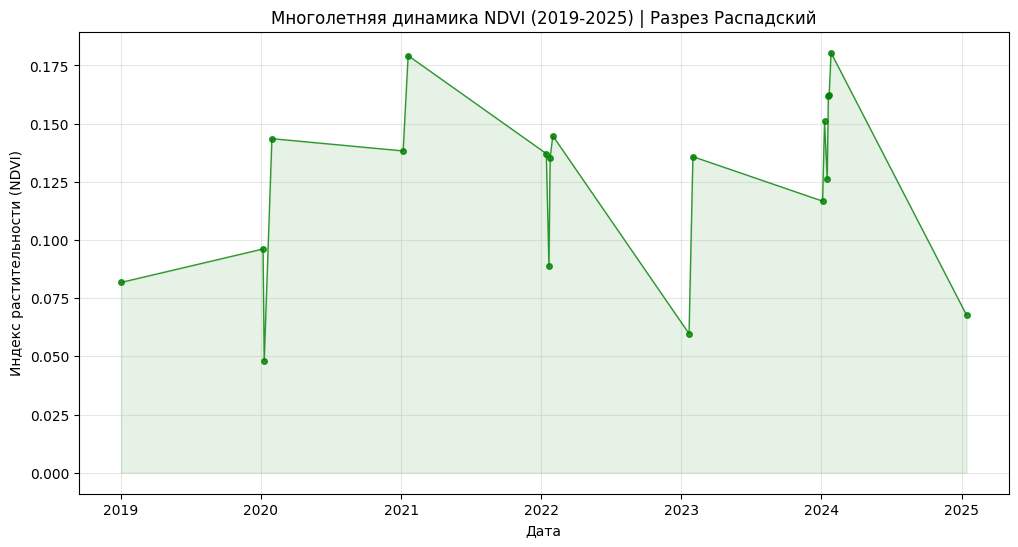

График построен по 19 снимкам. Чем выше пики в последние годы, тем лучше результат твоей работы!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Проверка области (ROI)
if Map.user_roi is not None:
    roi = Map.user_roi
else:
    roi = ee.Geometry.Point([88.15, 53.75]).buffer(500)

# 2. Сбор коллекции Sentinel-2
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(roi) \
    .filterDate('2019-01-01', '2025-12-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))

# 3. Функция расчета NDVI
def get_ndvi(img):
    ndvi_val = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
    mean_val = ndvi_val.reduceRegion(ee.Reducer.mean(), roi, 10).get('NDVI')
    return img.set('ndvi', mean_val).set('date', img.date().format('YYYY-MM-DD'))

# 4. Извлечение данных
features = collection.map(get_ndvi).filter(ee.Filter.notNull(['ndvi'])).aggregate_array('ndvi').getInfo()
dates = collection.map(get_ndvi).filter(ee.Filter.notNull(['ndvi'])).aggregate_array('date').getInfo()

# 5. Создание таблицы и графика с исправлением ошибки даты
df = pd.DataFrame({'NDVI': features, 'Date': dates})

# Исправленная строка для дат:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = df.dropna().sort_values('Date')

# 6. Визуализация
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['NDVI'], color='green', marker='o', markersize=4, linewidth=1, alpha=0.8)
plt.fill_between(df['Date'], df['NDVI'], color='green', alpha=0.1)

plt.title('Многолетняя динамика NDVI (2019-2025) | Разрез Распадский')
plt.xlabel('Дата')
plt.ylabel('Индекс растительности (NDVI)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"График построен по {len(df)} снимкам. Чем выше пики в последние годы, тем лучше результат твоей работы!")

# Новый раздел

In [ ]:
import ee
import geemap
import calendar

# 1. Инициализация проекта
PROJECT_ID = 'phd-monitoring-project'
ee.Initialize(project=PROJECT_ID)

# --- НАСТРОЙКИ ---
MONTH = 7 # Июль (пик вегетации)
LAT, LON = 53.788037, 88.162821
point = ee.Geometry.Point([LON, LAT])
roi = point.buffer(20000)

# Цветовая схема как в диссертации (7 цветов)
colors = ['#a50026', '#d73027', '#f46d43', '#ffffff', '#a6d96a', '#1a9850', '#006837']
# 7 меток для легенды (теперь ошибка уйдет)
labels = ['-0.2', '-0.1', '0.0', '0.1', '0.2', '0.3', '0.5']

def get_ndvi(year):
    start = f'{year}-{MONTH:02d}-01'
    end = f'{year}-{MONTH:02d}-{calendar.monthrange(year, MONTH)[1]}'
    img = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(roi)
        .filterDate(start, end)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
        .median().clip(roi))
    return img.normalizedDifference(['B8', 'B4']).rename(f'NDVI_{year}')

# 2. Получаем слои
ndvi_22 = get_ndvi(2022)
ndvi_23 = get_ndvi(2023)
ndvi_24 = get_ndvi(2024)

# 3. Создаем карту
Map = geemap.Map()
Map.setCenter(LON, LAT, 11)

# Добавляем все 3 года (ты сможешь переключать их в слоях справа)
Map.addLayer(ndvi_22, {'min': -0.1, 'max': 0.5, 'palette': colors}, 'NDVI 2022 (Широкий обзор)')
Map.addLayer(ndvi_23, {'min': -0.1, 'max': 0.5, 'palette': colors}, 'NDVI 2023')
Map.addLayer(ndvi_24, {'min': -0.1, 'max': 0.5, 'palette': colors}, 'NDVI 2024 (Широкий обзор)')

# Добавляем легенду (исправленную)
Map.add_legend(title=f"NDVI Comparison (July)", colors=colors, labels=labels)

Map

Map(center=[53.788037, 88.162821], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Sear…

In [ ]:
import ee
import geemap
import calendar

# 1. ИНИЦИАЛИЗАЦИЯ
PROJECT_ID = 'phd-monitoring-project' # Убедись, что это твой ID

try:
    ee.Initialize(project=PROJECT_ID)
except:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

# --- НАСТРОЙКИ ДЛЯ СКРИНШОТА ---
YEAR = 2023
MONTH = 7 # Меняй: 5-Май, 7-Июль, 9-Сентябрь
LAT, LON = 53.81173, 88.09258
# -------------------------------

point = ee.Geometry.Point([LON, LAT])
roi = point.buffer(3000)

start_date = f'{YEAR}-{MONTH:02d}-01'
end_date = f'{YEAR}-{MONTH:02d}-{calendar.monthrange(YEAR, MONTH)[1]}'

# Получаем лучший снимок
image = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
    .median().clip(roi))

ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

# Цветовая схема как на Рисунке 4.10
# 7 цветов и 7 меток - теперь всё совпадает
colors = ['#a50026', '#d73027', '#f46d43', '#ffffff', '#a6d96a', '#1a9850', '#006837']
labels = ['-0.2', '-0.1', '0.0', '0.1', '0.2', '0.3', '0.5']

Map = geemap.Map()
Map.setCenter(LON, LAT, 15)

# Слой NDVI
Map.addLayer(ndvi, {'min': -0.2, 'max': 0.5, 'palette': colors}, f'NDVI {MONTH}-{YEAR}')

# Легенда (теперь без ошибок)
Map.add_legend(title=f"NDVI {calendar.month_name[MONTH]} {YEAR}",
               colors=colors,
               labels=labels)

Map

Map(center=[53.81173, 88.09258], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Search…

In [2]:
import ee
import geemap
import calendar

# 1. АВТОРИЗАЦИЯ И ИНИЦИАЛИЗАЦИЯ
PROJECT_ID = 'phd-monitoring-project'

try:
    ee.Initialize(project=PROJECT_ID)
except:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

# --- НАСТРОЙКИ ---
YEARS = [2022, 2023, 2024]
MONTHS = [5, 7, 9] # Май, Июль, Сентябрь
LAT, LON = 53.788037, 88.162821 # Твои делянки на Распадском
ROI = ee.Geometry.Point([LON, LAT]).buffer(1500).bounds()

# Шкала как в диссертации
colors = ['#a50026', '#d73027', '#f46d43', '#ffffff', '#a6d96a', '#1a9850', '#006837']
labels = ['-0.2', '-0.1', '0.0', '0.1', '0.2', '0.3', '0.5']
ndvi_vis = {'min': -0.2, 'max': 0.5, 'palette': colors}

Map = geemap.Map()
Map.setCenter(LON, LAT, 12)

# 2. ГЕНЕРАЦИЯ 9 СЛОЕВ
for year in YEARS:
    for month in MONTHS:
        start_date = f'{year}-{month:02d}-01'
        end_date = f'{year}-{month:02d}-{calendar.monthrange(year, month)[1]}'

        # Получаем данные Sentinel-2
        img = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
            .filterBounds(ROI)
            .filterDate(start_date, end_date)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
            .median().clip(ROI))

        ndvi = img.normalizedDifference(['B8', 'B4']).rename(f'NDVI_{month}_{year}')

        # Название для списка слоев (например, "NDVI May 2022")
        layer_name = f'NDVI {calendar.month_name[month]} {year}'

        # Добавляем на карту (False значит, что слой будет загружен, но скрыт)
        Map.addLayer(ndvi, ndvi_vis, layer_name, False)

# Добавляем легенду один раз
Map.add_legend(title="NDVI Vegetation Index", colors=colors, labels=labels)

Map

Map(center=[53.788037, 88.162821], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Sear…

In [9]:
import ee
import geemap
import calendar

# 1. АВТОРИЗАЦИЯ
PROJECT_ID = 'phd-monitoring-project'
try:
    ee.Initialize(project=PROJECT_ID)
except:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

# --- ПАРАМЕТРЫ ---
LAT, LON = 53.788037, 88.162821
ROI = ee.Geometry.Point([LON, LAT]).buffer(10000).bounds()

ndvi_palette = ['#a50026', '#d73027', '#f46d43', '#ffffff', '#e6f598', '#abdb67', '#66bd63', '#1a9850']
ndvi_labels = ['-0.2', '-0.1', '0.0', '0.1', '0.2', '0.3', '0.4', '0.5']
ndvi_vis = {'min': -0.2, 'max': 0.5, 'palette': ndvi_palette}

Map = geemap.Map()
Map.setCenter(LON, LAT, 12)

# 2. ФУНКЦИЯ ПОЛУЧЕНИЯ NDVI (универсальная)
def get_ndvi_for_date(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(28, 'day')
    img = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(ROI)
           .filterDate(start, end)
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
           .median().clip(ROI))
    return img.normalizedDifference(['B8', 'B4'])

# 3. ЦИКЛ ДЛЯ ИСТОРИЧЕСКИХ СЛОЕВ (2022-2024)
YEARS = [2022, 2023, 2024]
MONTHS = [5, 7, 9]

for year in YEARS:
    for month in MONTHS:
        ndvi = get_ndvi_for_date(year, month)
        Map.addLayer(ndvi, ndvi_vis, f'NDVI {calendar.month_name[month]} {year}', False)

# --- ИСПРАВЛЕННЫЙ ПРОГНОЗ (Решаем проблему со скрина image_a61732.png) ---
def calculate_trend(year_num):
    # Используем функции ee.Number и ee.Date для работы на стороне сервера
    year = ee.Number(year_num)
    ndvi = get_ndvi_for_date(year, 7) # Берем июль для тренда
    # Добавляем временную полосу 't' (годы с 2022)
    return ndvi.addBands(ee.Image(year.subtract(2022)).float().rename('t'))

# Создаем коллекцию через ee.List для стабильности
years_ee = ee.List(YEARS)
collection = ee.ImageCollection(years_ee.map(calculate_trend))

# Считаем линейный тренд
trend = collection.reduce(ee.Reducer.linearFit())

# NDVI_2027 = (scale * 5 лет) + offset
ndvi_2027 = trend.select('scale').multiply(5).add(trend.select('offset')).clip(ROI)

Map.addLayer(ndvi_2027, ndvi_vis, 'PROJECTION 2027', True)

# 4. ЛЕГЕНДА
Map.add_legend(title="NDVI Vegetation Index", colors=ndvi_palette, labels=ndvi_labels)

Map

Map(center=[53.788037, 88.162821], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Sear…